# 💰 Previsão de salários

## 1. Introdução

Este projeto utiliza um conjunto de dados sintético desenvolvido para estudos de previsão salarial, modelagem de regressão e análise de dados aplicada à área de recursos humanos.

O dataset simula relações realistas entre diferentes fatores profissionais e organizacionais, incluindo cargo, anos de experiência, nível de formação acadêmica, quantidade de habilidades, certificações e características das empresas. Esses elementos são utilizados para estimar salários de profissionais em diferentes setores, tamanhos de empresa e localidades.

Por se tratar de um conjunto de dados estruturado com múltiplas variáveis explicativas, ele é adequado para a prática de técnicas de ciência de dados, incluindo análise exploratória de dados (EDA), engenharia de atributos e desenvolvimento de modelos de aprendizado de máquina voltados para problemas de regressão.

O objetivo deste projeto é analisar os fatores que influenciam a variação salarial e desenvolver um modelo capaz de estimar salários com base nas características profissionais e organizacionais presentes no dataset.

---

## 2. Problema de Negócio

A definição de salários dentro de empresas pode ser influenciada por diversos fatores, como experiência profissional, nível educacional, habilidades técnicas, certificações e características da organização. Compreender como esses fatores se relacionam com a remuneração é importante tanto para profissionais que desejam entender melhor o mercado de trabalho quanto para empresas que buscam estruturar políticas salariais mais consistentes.

Entretanto, identificar quais variáveis possuem maior impacto na remuneração pode ser uma tarefa complexa quando analisada apenas de forma intuitiva. Nesse contexto, a análise de dados e o uso de técnicas de aprendizado de máquina podem auxiliar na identificação de padrões e relações entre as características profissionais e os salários observados.

Dessa forma, o problema central deste projeto consiste em investigar como diferentes fatores profissionais e organizacionais influenciam o salário e verificar se é possível construir um modelo capaz de estimar a remuneração com base nessas características.

A partir dessa análise, busca-se responder à seguinte questão:

**É possível prever o salário de um profissional com base em informações como cargo, experiência, nível educacional, habilidades, certificações e características da empresa?**

---

## 3. Hipóteses Iniciais

Antes de realizar a análise exploratória dos dados, algumas hipóteses foram formuladas com base em conhecimento geral sobre o mercado de trabalho e fatores que costumam influenciar a remuneração profissional.

Essas hipóteses servirão como ponto de partida para orientar a análise e serão verificadas ao longo do projeto por meio de estatísticas descritivas, visualizações e modelagem preditiva.

As principais hipóteses consideradas são:

- **Cargo (job_title)** possui forte influência sobre o salário base, uma vez que diferentes funções apresentam níveis distintos de responsabilidade e especialização.

- **Nível educacional (education_level)** pode impactar a remuneração, já que formações mais avançadas podem indicar maior qualificação profissional.

- **Anos de experiência (experience_years)** devem apresentar correlação positiva com o salário, pois profissionais mais experientes tendem a receber remunerações mais altas.

- **Número de habilidades (skills_count)** pode influenciar o salário, considerando que profissionais com maior diversidade de competências podem agregar mais valor às organizações.

- **Certificações (certifications)** podem impactar a remuneração ao demonstrar especialização em determinadas áreas.

- **Tamanho da empresa (company_size)** pode influenciar os salários, já que empresas maiores frequentemente possuem maior capacidade financeira para remuneração.

- **Modalidade de trabalho (remote_work)** pode apresentar diferenças salariais em comparação com posições presenciais, dependendo da política das empresas e da localização.

Ao longo do projeto, essas hipóteses serão avaliadas utilizando análise exploratória de dados e técnicas de modelagem para identificar quais fatores possuem maior impacto na previsão salarial.

---

## 4. Descrição do Dataset

O conjunto de dados utilizado neste projeto contém informações relacionadas a características profissionais, educacionais e organizacionais que podem influenciar a remuneração de um indivíduo.

A tabela abaixo apresenta a descrição das variáveis presentes no dataset:

| Coluna | Descrição |
|------|-----------|
| **job_title** | Cargo ou função exercida pelo profissional. |
| **experience_years** | Número de anos de experiência profissional. |
| **education_level** | Nível de formação acadêmica do profissional. |
| **skills_count** | Quantidade de habilidades registradas para o profissional. |
| **industry** | Setor ou indústria em que a empresa atua. |
| **company_size** | Tamanho da empresa em que o profissional trabalha. |
| **location** | Localização geográfica da empresa ou do profissional. |
| **remote_work** | Indica se o trabalho é remoto ou presencial. |
| **certifications** | Número de certificações profissionais obtidas. |
| **salary** | Salário estimado do profissional, representando a variável alvo do modelo de previsão. |

---

## 5. Carregamento dos Dados

### Visualização inicial do dataset

Para compreender a estrutura inicial dos dados, exibimos as primeiras linhas do dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('job_salary_prediction_dataset.csv')

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [3]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [4]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['job_title'].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

### Distribuição de cargos

A análise da frequência dos cargos mostra que o dataset apresenta uma distribuição bastante equilibrada entre as diferentes funções.

A menor frequência observada foi de aproximadamente 20.633 registros, enquanto a maior foi de cerca de 21.125 registros. Essa diferença relativamente pequena indica que o conjunto de dados é bem balanceado em relação aos cargos, o que é uma característica comum em datasets sintéticos desenvolvidos para treinamento de modelos de aprendizado de máquina.

Esse equilíbrio é positivo para a modelagem, pois reduz o risco de viés associado a categorias com grande predominância no conjunto de dados.

In [7]:
df['education_level'].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [8]:
df.nunique().sort_values()

remote_work              3
education_level          5
company_size             5
certifications           6
location                10
industry                10
job_title               12
skills_count            19
experience_years        21
salary              118956
dtype: int64

In [9]:
df.groupby("job_title")["salary"].mean().sort_values(ascending=False)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64

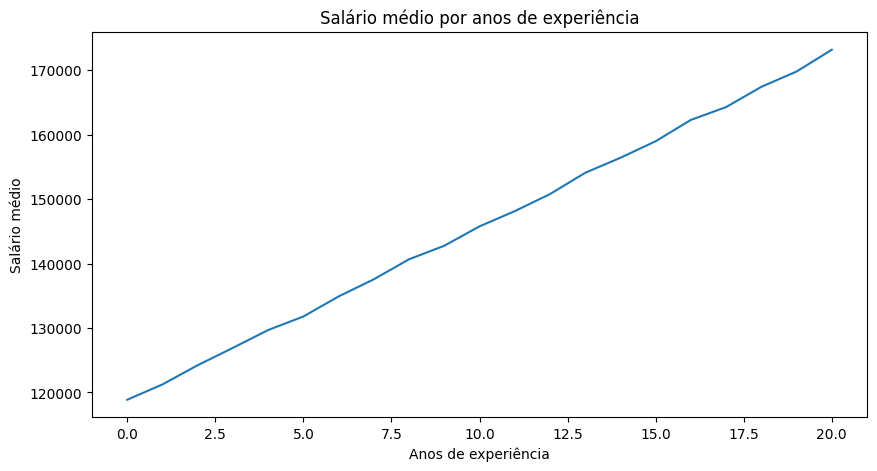

In [11]:
salary_by_experience = df.groupby("experience_years")["salary"].mean()

plt.figure(figsize=(10,5))
salary_by_experience.plot()

plt.title("Salário médio por anos de experiência")
plt.xlabel("Anos de experiência")
plt.ylabel("Salário médio")
plt.show()

### Relação entre experiência e salário

O gráfico mostra uma tendência clara de aumento do salário médio conforme os anos de experiência aumentam. No entanto, esse crescimento não apresenta comportamento exponencial. Em vez disso, observa-se um padrão relativamente linear, indicando que os salários aumentam de forma gradual ao longo da carreira.

Esse comportamento é consistente com a dinâmica de muitas carreiras profissionais, nas quais o crescimento salarial ocorre por meio de progressões de cargo, promoções e ajustes salariais periódicos, resultando em incrementos relativamente constantes ao longo do tempo.

In [12]:
df.groupby("experience_years")["salary"].mean().diff()

experience_years
0             NaN
1     2377.904428
2     2978.416666
3     2692.659262
4     2767.180323
5     2098.467282
6     3111.045995
7     2662.513655
8     3106.952364
9     2096.071952
10    3008.138315
11    2361.200238
12    2645.860003
13    3303.582883
14    2330.536764
15    2567.988751
16    3309.725344
17    1991.314443
18    3139.004414
19    2376.176605
20    3382.347208
Name: salary, dtype: float64